In [5]:
import os
import torch
import json
import jsonlines
import numpy as np
import seaborn as sns  
import random
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import matplotlib as mpl

In [6]:
mpl.rcParams['font.family'] = 'serif' 
mpl.rcParams['font.serif'] = ['Times New Roman']  
mpl.rcParams['font.size'] = 12

mpl.rcParams['text.color'] = 'black'

mpl.rcParams['font.weight'] = 'normal'
from scipy.stats import pearsonr

In [9]:
def get_shape(obj):
    """
    该函数递归地推断嵌套 tensor / list / tuple 结构的维度信息，
    返回类似 shape 的多维长度列表，本质是对规则嵌套结构的维度展开。
    """
    if isinstance(obj, torch.Tensor):
        return list(obj.shape)
    elif isinstance(obj, (list, tuple)):
        return [len(obj)] + get_shape(obj[0]) if len(obj) > 0 else []
    else:
        return []

In [10]:
def load_acd_scores(file_path,pt_name):
    acd_score_path = file_path+pt_name
    check_result_path = file_path+'/output_judge.jsonl'
    acd_scores = torch.load(acd_score_path)
    check_result = []
    with jsonlines.open(check_result_path) as reader:
        for obj in reader:
            check_result.append({'id': obj['id'], 'result': obj['result_type']})
    return acd_scores, check_result

In [11]:
def mean_of_layer(lst):
    layer_mean_value = []
    for layer in lst:
        layer_mean_value.append(sum(layer) / len(layer))
    return layer_mean_value

In [12]:
def read_acd_scores(file_path, pt_name, sample_equal=False):
    acd_scores, check_result = load_acd_scores(file_path,pt_name)
    acd_scores_correct,acd_scores_wrong = [],[]

    for item in check_result:
        (key, value) = (item['id'], item['result'])
        if value == 1:
            acd_scores_correct.append(np.array(acd_scores[key]))
        elif value == 0:
            acd_scores_wrong.append(np.array(acd_scores[key]))
            
    # random samples to make the number of correct and wrong samples equal
    if sample_equal:
        n_samples = min(len(acd_scores_wrong), len(acd_scores_correct))
        acd_scores_correct = random.sample(acd_scores_correct,n_samples)
        acd_scores_wrong = random.sample(acd_scores_wrong,n_samples) # [item, layer, token]
    print('correct length:',len(acd_scores_correct), 'wrong length:',len(acd_scores_wrong))

    # [item, layer, token] -> [item, layer]
    layer_acd_correct = [np.mean(item,axis=-1) for item in acd_scores_correct] # [item, layer]
    layer_acd_wrong = [np.mean(item,axis=-1) for item in acd_scores_wrong]
 
    return layer_acd_correct, layer_acd_wrong 

In [13]:
def load_acd_scores(file_path,pt_name):
    acd_score_path = file_path+pt_name
    check_result_path = file_path+'/output_judge.jsonl'
    acd_scores = torch.load(acd_score_path)
    check_result = []
    with jsonlines.open(check_result_path) as reader:
        for obj in reader:
            check_result.append({'id': obj['id'], 'result': obj['result_type']})
    return acd_scores, check_result

In [14]:
def read_acd_scores_all(file_paths,pt_name):
    layer_acd = {}
    for dataset,file_path in file_paths.items():
        acd_scores, check_result = load_acd_scores(file_path,pt_name)
        layer_acd_scores = [np.mean(acd_scores[key],axis=-1) for key in acd_scores.keys()]
        layer_acd[dataset] = layer_acd_scores
    return layer_acd

In [15]:
def plot_acd_lineplot(layer_acd):
    plt.figure(figsize=(12, 8))
    all_curves = []  
    colors = ['blue', 'green', 'red', 'orange']
    linestyles = ['-', '-', '-', '-']
    markers = ['o', 'o', 'o', 'o']

    for idx, key in enumerate(layer_acd):
        mean_acd_scores = np.mean(layer_acd[key], axis=0)[:-1]
        x = np.arange(len(mean_acd_scores))
        plt.plot(x, mean_acd_scores,
                 label=key,
                 marker=markers[idx % len(markers)],
                 linestyle=linestyles[idx % len(linestyles)],
                 color=colors[idx % len(colors)],
                 linewidth=1,      
                 alpha=0.5,        
                    markersize=1.5)
        all_curves.append(mean_acd_scores)

In [16]:
def plot_acd_ribbon(layer_acd):
    fig, ax = plt.subplots(figsize=(15, 10))
    all_curves = []
    for key in layer_acd:
        mean_scores = np.mean(layer_acd[key], axis=0)[:-1]
        all_curves.append(mean_scores)
    all_curves = np.array(all_curves)
    overall_mean = np.mean(all_curves, axis=0)
    overall_std = np.std(all_curves, axis=0)

    x = np.arange(len(overall_mean))
    ax.grid(True, axis='y', linestyle='--', linewidth=1.2, color='gray', alpha=0.3)
    ax.grid(False, axis='x')
    ax.plot(x, overall_mean, label='Overall Mean', color='blue', linestyle='--', linewidth=3, alpha=1)
    ax.fill_between(x, overall_mean - overall_std*1.5, overall_mean + overall_std*1.5,
                    color='blue', alpha=0.15, label='Std Dev')
    
    ax.set_title("Layer-wise ICR Score Evolution", fontsize=42, pad=15)
    ax.set_xlabel("Layer", fontsize=40, labelpad=15) 
    ax.set_ylabel("ICR Score", fontsize=40, labelpad=15)
    
    plt.xticks(fontsize=37)
    plt.yticks(fontsize=35)

    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    leg = ax.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=33, loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [17]:
def mean_of_2d_list(lst):
    flat_list = [item for sublist in lst for item in sublist]

    if not flat_list:
        return 0
    mean_value = sum(flat_list) / len(flat_list)
    return mean_value

In [18]:
model = "qwen3"

In [21]:
file_paths = {
    'halu_eval': '/home/sjx/hallucination/ICR_Probe/saves/halu_eval/qwen3_halu_eval_qa_KQA'
}

In [24]:
pt_name = '/icr_score.pt'

In [25]:
layer_acd = read_acd_scores_all(file_paths, pt_name)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

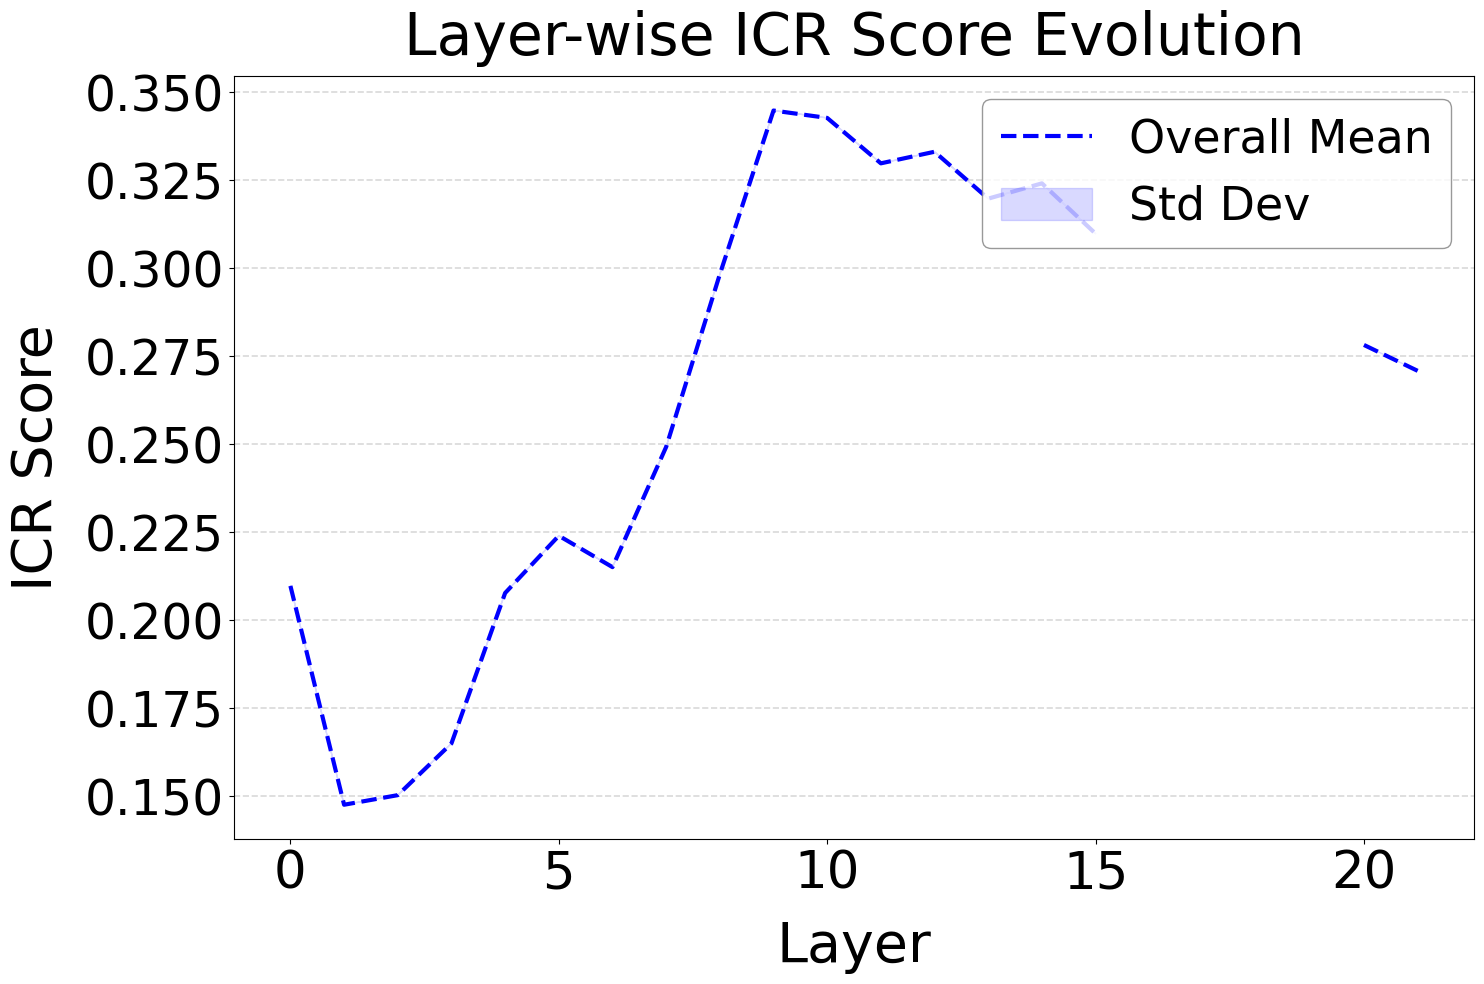

In [26]:
plot_acd_ribbon(layer_acd)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

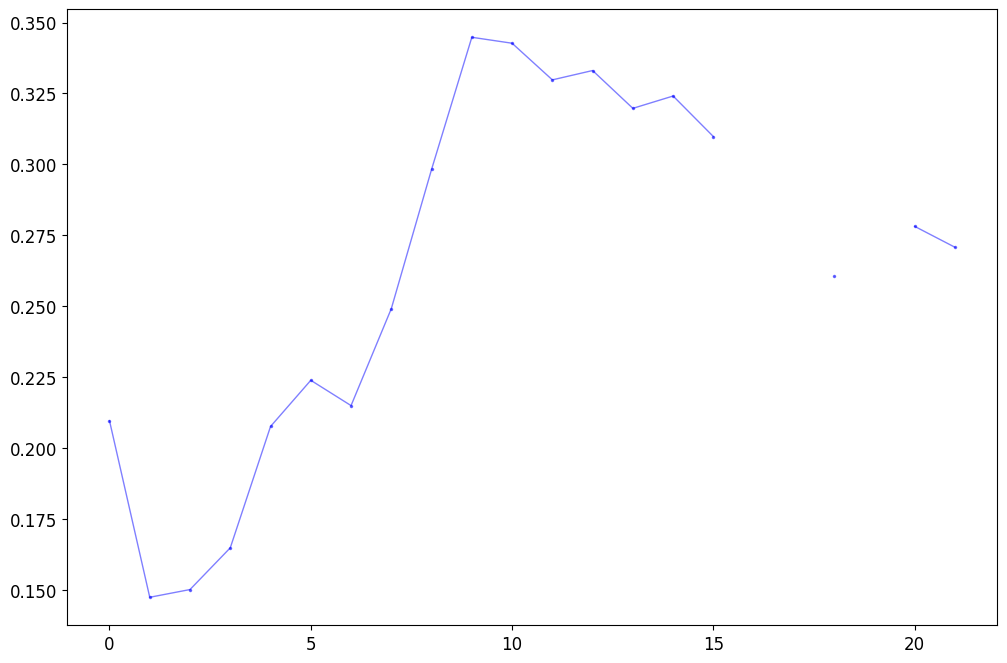

In [27]:
plot_acd_lineplot(layer_acd)

In [31]:
file_paths = file_paths['halu_eval']
layer_acd_correct, layer_acd_wrong = read_acd_scores(file_paths, pt_name, sample_equal=False)

correct length: 4984 wrong length: 5016


In [32]:
layer_acd_correct = np.array(layer_acd_correct)

In [33]:
layer_acd_wrong = np.array(layer_acd_wrong)

In [34]:
num_layers = layer_acd_correct.shape[1]

In [35]:
num_layers

36

In [36]:
auroc_scores = []

In [ ]:
for layer in range(num_layers):
    y_true = np.concatenate([np.ones(len(layer_acd_correct)), np.zeros(len(layer_acd_wrong))])
    y_score = np.concatenate([layer_acd_correct[:, layer], layer_acd_wrong[:, layer]])
    auroc = roc_auc_score(y_true, y_score)
    auroc = max(auroc, 1 - auroc)  
    print(f"Layer {layer}: AUROC = {auroc:.4f}")
    auroc_scores.append(auroc)

Layer 0: AUROC = 0.6127
Layer 1: AUROC = 0.6181
Layer 2: AUROC = 0.6132
Layer 3: AUROC = 0.6217
Layer 4: AUROC = 0.5039
Layer 5: AUROC = 0.6380
Layer 6: AUROC = 0.6929
Layer 7: AUROC = 0.8078
Layer 8: AUROC = 0.6920
Layer 9: AUROC = 0.5741
Layer 10: AUROC = 0.5102
Layer 11: AUROC = 0.7079
Layer 12: AUROC = 0.5674
Layer 13: AUROC = 0.6688
Layer 14: AUROC = 0.7072
Layer 15: AUROC = 0.7487
